<h1>Tarea 8 Algoritmo K-means: clasificador de vinos </h1>
    <h3 style="color:blue">José Luis Romero Vázquez </h3>
    <h3 style="color:blue">03/06/23</h3>

**1. Cargue el dataset de vinos con el siguiente código de Python:**

In [ ]:
import matplotlib.pyplot as plt
from sklearn import datasets
wine=datasets.load_wine()
wine.keys()


dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])

**2. Revise la descripción del dataset con el siguiente comando:
print(wine['DESCR'])**

In [ ]:
print(wine['DESCR'])

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

    :Number of Instances: 178
    :Number of Attributes: 13 numeric, predictive attributes and the class
    :Attribute Information:
 		- Alcohol
 		- Malic acid
 		- Ash
		- Alcalinity of ash  
 		- Magnesium
		- Total phenols
 		- Flavanoids
 		- Nonflavanoid phenols
 		- Proanthocyanins
		- Color intensity
 		- Hue
 		- OD280/OD315 of diluted wines
 		- Proline

    - class:
            - class_0
            - class_1
            - class_2
		
    :Summary Statistics:
    
    ============================= ==== ===== ======= =====
                                   Min   Max   Mean     SD
    ============================= ==== ===== ======= =====
    Alcohol:                      11.0  14.8    13.0   0.8
    Malic Acid:                   0.74  5.80    2.34  1.12
    Ash:                          1.36  3.23    2.36  0.27
    Alcalinity of Ash:            10.6  30.0    19.5   3.3
    Ma

**3. Muestre los registros de las características del dataset (wine['data']) y de las 
categorías de vino (wine['target']).
wine['data']**

In [ ]:
print(wine['data'])
print (wine['target'])

[[1.423e+01 1.710e+00 2.430e+00 ... 1.040e+00 3.920e+00 1.065e+03]
 [1.320e+01 1.780e+00 2.140e+00 ... 1.050e+00 3.400e+00 1.050e+03]
 [1.316e+01 2.360e+00 2.670e+00 ... 1.030e+00 3.170e+00 1.185e+03]
 ...
 [1.327e+01 4.280e+00 2.260e+00 ... 5.900e-01 1.560e+00 8.350e+02]
 [1.317e+01 2.590e+00 2.370e+00 ... 6.000e-01 1.620e+00 8.400e+02]
 [1.413e+01 4.100e+00 2.740e+00 ... 6.100e-01 1.600e+00 5.600e+02]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


**4. Para la etapa de preprocesamiento de la tubería (pipeline) aplique la normalización 
de MinMaxScaler y un análisis de componentes principales (PCA) para dos 
componentes.**

In [ ]:
import tarfile
import urllib

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

preprocessor = Pipeline(
    [
        ("scaler", MinMaxScaler()),
        ("pca", PCA(n_components=2, random_state=42)),
    ]
)

**5. Configure el algoritmo de agrupamiento K-means del pipeline con los siguientes 
parámetros:**

In [ ]:
clusterer = Pipeline(
    [
        (
            "kmeans",
            KMeans(
                n_clusters=3,
                init="k-means++",
                n_init=50,
                max_iter=5000,
                random_state=42,
            ),
        ),
    ]
)

In [ ]:
pipe = Pipeline([("preprocessor", preprocessor), ("clusterer", clusterer)])

**6. Entrene el modelo con los datos del dataset (wine['data'])**

In [ ]:
pipe.fit(wine.data)

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('scaler', MinMaxScaler()),
                                 ('pca',
                                  PCA(n_components=2, random_state=42))])),
                ('clusterer',
                 Pipeline(steps=[('kmeans',
                                  KMeans(max_iter=5000, n_clusters=3, n_init=50,
                                         random_state=42))]))])

**7. Consulte el resultado del agrupamiento de K-means**

In [ ]:
preprocessed_data = pipe["preprocessor"].transform(wine.data)
preprocessed_data

array([[-7.06335756e-01, -2.53192753e-01],
       [-4.84976802e-01, -8.82289142e-03],
       [-5.21172266e-01, -1.89187222e-01],
       [-8.21643663e-01, -5.80905512e-01],
       [-2.02546382e-01, -5.94665740e-02],
       [-6.08190152e-01, -4.87519191e-01],
       [-5.44047399e-01, -3.00196497e-01],
       [-4.74357495e-01, -2.98197021e-01],
       [-5.00432012e-01, -3.07602859e-01],
       [-6.27517969e-01, -2.06328233e-01],
       [-7.27467157e-01, -3.56512044e-01],
       [-3.74967744e-01, -2.25424535e-01],
       [-4.48188283e-01, -2.31938139e-01],
       [-6.26345329e-01, -3.55138677e-01],
       [-8.35717011e-01, -5.38047802e-01],
       [-4.71931568e-01, -3.37405385e-01],
       [-4.26990905e-01, -4.50842684e-01],
       [-3.66595704e-01, -3.15750341e-01],
       [-7.18788533e-01, -5.93881332e-01],
       [-4.58884986e-01, -1.75782240e-01],
       [-6.61852288e-01, -1.27831032e-01],
       [-2.67900032e-01,  9.81127565e-03],
       [-5.99782399e-01,  7.82494523e-04],
       [-4.

**8. Realice las gráficas del agrupamiento real (wine[‘target’]) y del agrupamiento con Kmeans para analizar qué tan acertada fue la agrupación**

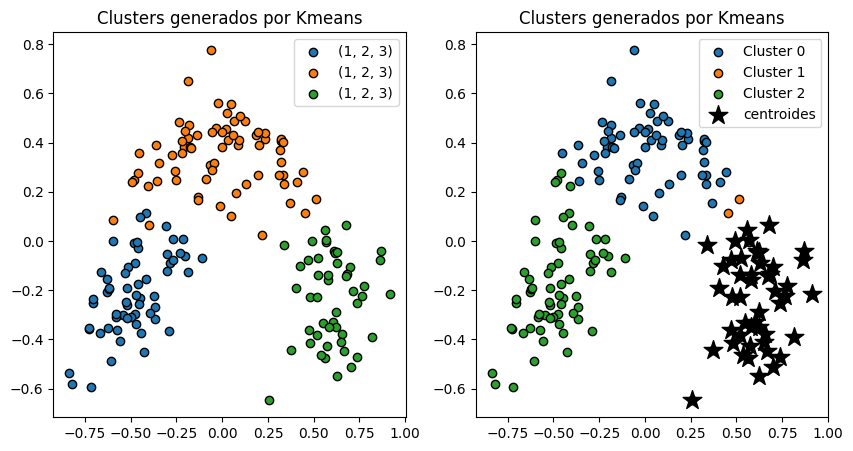

In [ ]:
# Clasificación con el modelo kmeans
# ==============================================================================
y_predict = pipe["clusterer"]["kmeans"].labels_

# Representación gráfica: grupos originales vs clusters creados
# ==============================================================================
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Grupos originales
for i in np.unique(wine['target']):
    ax[0].scatter(
        x = preprocessed_data[wine['target'] == i, 0],
        y = preprocessed_data[wine['target'] == i, 1], 
        c = plt.rcParams['axes.prop_cycle'].by_key()['color'][i],
        marker    = 'o',
        edgecolor = 'black', 
        label=(1,2,3)
    )
ax[0].set_title('Clusters generados por Kmeans')
ax[0].legend();

for i in np.unique(pipe["clusterer"]["kmeans"].labels_):
    ax[1].scatter(
        x = preprocessed_data[pipe["clusterer"]["kmeans"].labels_ == i, 0],
        y = preprocessed_data[pipe["clusterer"]["kmeans"].labels_ == i, 1], 
        c = plt.rcParams['axes.prop_cycle'].by_key()['color'][i],
        marker    = 'o',
        edgecolor = 'black', 
        label= f"Cluster {i}"
    )
    
ax[1].scatter(
   x = pipe["preprocessor"].transform(wine['data'])[wine['target'] == i, 0],
y = pipe["preprocessor"].transform(wine['data'])[wine['target'] == i, 1],
    c = 'black',
    s = 200,
    marker = '*',
    label  = 'centroides'
)
ax[1].set_title('Clusters generados por Kmeans')
ax[1].legend();

**9. Genere la matriz de confusión para saber que tanto se equivocó el algoritmo**

In [ ]:
pd.crosstab(wine['target'], pipe["clusterer"]["kmeans"].labels_, dropna=False, rownames=['grupo_real'], colnames=['cluster'])

cluster,0,1,2
grupo_real,,,
0,0,0,59
1,62,3,6
2,0,48,0


**10.Realice el análisis de ARI para determinar cuántos componentes principales nos 
conviene tomar para este problema usando el rango 2-13.
*NOTA: solo grafique ARI, y no silueta para que se visualice mejor el resultado.**

In [ ]:
# Empty lists to hold evaluation metrics
silhouette_scores = []
ari_scores = []
for n in range(2, 13):
    # This set the number of components for pca,
    # but leaves other steps unchanged
    pipe["preprocessor"]["pca"].n_components = n
    pipe.fit(wine['data'])

    silhouette_coef = silhouette_score(
        pipe["preprocessor"].transform(wine['data']),
        pipe["clusterer"]["kmeans"].labels_,
    )
    ari = adjusted_rand_score(
        wine['target'],
        pipe["clusterer"]["kmeans"].labels_,
    )


    # Add metrics to their lists
    silhouette_scores.append(silhouette_coef)
    ari_scores.append(ari)

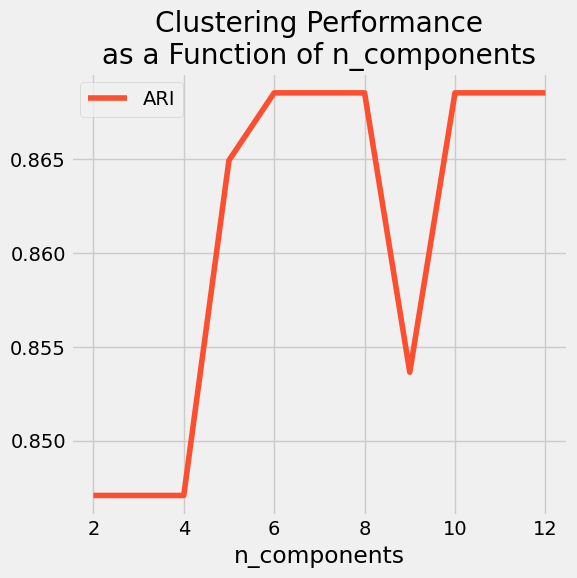

In [ ]:
plt.style.use("fivethirtyeight")
plt.figure(figsize=(6, 6))

plt.plot(range(2, 13), ari_scores, c="#fc4f30", label="ARI")
#plt.plot(range(2, 11), inertias, marker='o',label="elbow")

 

plt.xlabel("n_components")
plt.legend()
plt.title("Clustering Performance\nas a Function of n_components")
plt.tight_layout()
plt.show()

**11.Con el resultado anterior vuelva a crear y entrenar el modelo. Recuerde que por ser 
una tubería solo tiene que ejecutar 2 líneas**

In [ ]:
pipe["preprocessor"]["pca"].n_components = 10
pipe.fit(wine['data'])

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('scaler', MinMaxScaler()),
                                 ('pca',
                                  PCA(n_components=10, random_state=42))])),
                ('clusterer',
                 Pipeline(steps=[('kmeans',
                                  KMeans(max_iter=5000, n_clusters=3, n_init=50,
                                         random_state=42))]))])

**12.Grafique la nueva agrupación y genere la matriz de confusión**

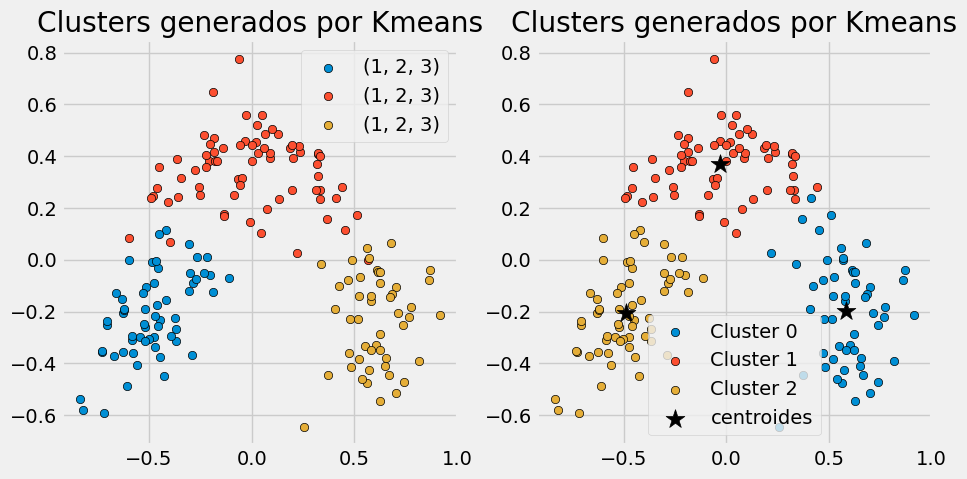

In [ ]:
# Clasificación con el modelo kmeans

 

# ==============================================================================

 

y_predict = pipe["clusterer"]["kmeans"].labels_

 

# Representación gráfica: grupos originales vs clusters creados

 

# ==============================================================================

 

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
# Grupos originales

 

for i in np.unique(wine['target']):

 

    ax[0].scatter(

 

    
   x = pipe["preprocessor"].transform(wine['data'])[wine['target'] == i, 0],

 

y = pipe["preprocessor"].transform(wine['data'])[wine['target'] == i, 1],

 

        c = plt.rcParams['axes.prop_cycle'].by_key()['color'][i],

 

        marker    = 'o',

 

        edgecolor = 'black',

 

        label=(1,2,3)

 

    )

 

ax[0].set_title('Clusters generados por Kmeans')

 

ax[0].legend();

 

 


for i in np.unique(pipe["clusterer"]["kmeans"].labels_):

 

    ax[1].scatter(

 

        x = preprocessed_data[pipe["clusterer"]["kmeans"].labels_ == i, 0],

 

        y = preprocessed_data[pipe["clusterer"]["kmeans"].labels_ == i, 1],

 

        c = plt.rcParams['axes.prop_cycle'].by_key()['color'][i],

 

        marker    = 'o',

 

        edgecolor = 'black',

 

        label= f"Cluster {i}"

 

    )

 

   

 

ax[1].scatter(

 

   x = pipe["clusterer"]["kmeans"].cluster_centers_[:, 0],
    y = pipe["clusterer"]["kmeans"].cluster_centers_[:, 1],

 

    c = 'black',

 

    s = 200,

 

    marker = '*',

 

    label  = 'centroides'

 

)

 

ax[1].set_title('Clusters generados por Kmeans')

 

ax[1].legend();

In [ ]:
pd.crosstab(wine['target'], pipe["clusterer"]["kmeans"].labels_, dropna=False, rownames=['grupo_real'], colnames=['cluster'])

cluster,0,1,2
grupo_real,,,
0,0,0,59
1,6,63,2
2,48,0,0


**13.Usando las funciones purity_score y pyPurity haga un análisis de agrupamiento 
k-means con las siguientes métricas:**

In [ ]:
pip install pyclustering

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 24.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyclustering: filename=pyclustering-0.10.1.2-py3-none-any.whl size=2395106 sha256=2527755bddca8fd20a0826345b6cf6ec2217b4920b1868f56e0b1b62477fcef6
  Stored in directory: /root/.cache/pip/wheels/b5/42/97/11eee99f5c1e4fdfc170f0a54f9c9eb195df66edb4cf69f449
Successfully built pyclustering


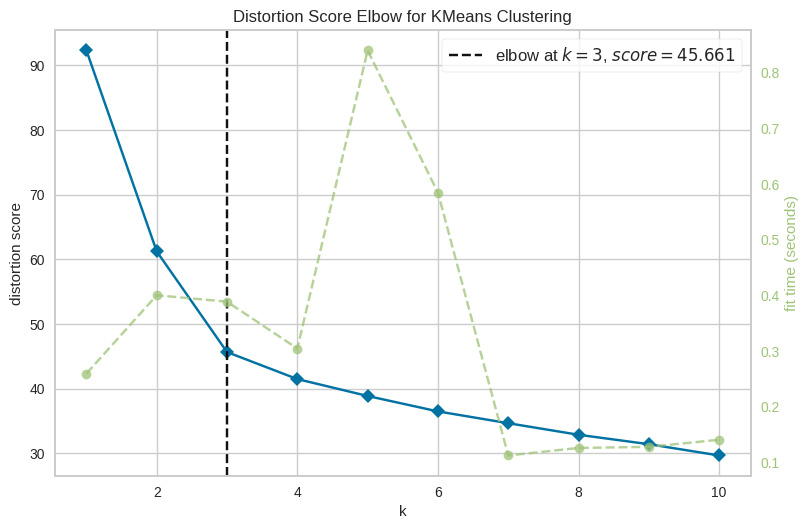

The purity score is cluster
0    314.81
1    269.84
2    278.69
dtype: float64%
Purity score con distancia Euclidiana: cluster
0    314.81
1    269.84
2    278.69
dtype: float64%
Purity score con distancia Euclidiana cuadrada: cluster
0    314.81
1    269.84
2    278.69
dtype: float64%
Purity score con distancia Manhattan: cluster
0    314.81
1    269.84
2    278.69
dtype: float64%
Purity score con distancia Chebyshev: cluster
0    314.81
1    269.84
2    278.69
dtype: float64%
Purity score con distancia Canberra: cluster
0    314.81
1    269.84
2    278.69
dtype: float64%
Purity score con distancia Chi-square: cluster
0    314.81
1    269.84
2    278.69
dtype: float64%


In [ ]:
from pyclustering.cluster.kmeans import kmeans
from pyclustering.utils.metric import distance_metric
from pyclustering.cluster.center_initializer import random_center_initializer
from pyclustering.cluster.encoder import type_encoding
from pyclustering.cluster.encoder import cluster_encoder
# sklearn kmeans
from sklearn.cluster import KMeans
from sklearn.metrics.cluster import contingency_matrix
 #data visualization
import matplotlib.pyplot as plt
%matplotlib inline
from yellowbrick.cluster import KElbowVisualizer # cluster visualizer


import math
X=pipe["preprocessor"].transform(wine['data'])

# Instantiate the clustering model and visualizer
model = KMeans(n_init=50)
visualizer = KElbowVisualizer(model, k=(1, 11))

visualizer.fit(X) # Fit the data to the visualizer
visualizer.show() # Finalize and render the figure
plt.show()
def purity_score(y_true, y_pred):
    # compute contingency matrix (also called confusion matrix)
    confusion_matrix = pd.crosstab(wine['target'], pipe["clusterer"]["kmeans"].labels_, dropna=False, rownames=['grupo_real'], colnames=['cluster'])
    # return purity
    return np.sum(np.amax(confusion_matrix, axis=0)) / np.sum(confusion_matrix)
# instatiate KMeans class and set the number of clusters
km_model = KMeans(n_clusters=3, random_state=10, n_init=50)

# call fit method with data 
km = km_model.fit_predict(X)

# coordinates of cluster center
centroids = km_model.cluster_centers_ 

# cluster label for each data point
labels = km_model.labels_ 
# Report Purity Score
purity = purity_score(X, labels)
print(f"The purity score is {round(purity*100, 2)}%")

def distanciaE(point1, point2):
     distance = 0.0
     for i in range(len(point1)):
         distance += (point1[i] - point2[i]) ** 2.0
     return math.sqrt(distance)
def distanciaAVE(point1, point2):
     distance = 0.0
     for i in range(len(point1)):
         distance += (point1[i] - point2[i]) ** 2.0
     return math.sqrt(distance/len(point1))

def distanciaWE(point1, point2):
    # W=(0.4,0.3,0.2,0.1) #86.67
     #W=(0.3,0.2,0.4,0.1) #89.33   
     #W=(0.1,0.2,0.3,0.4) #91.33
     W=(0.1,0.1,0.1,0.7)  #96
     distance = 0.0
     for i in range(len(point1)):
         distance += W[i]*(point1[i] - point2[i]) ** 2.0
     return math.sqrt(distance)


# define dictionary for distance measures
distance_measures = {'Euclidiana': 0, 'Euclidiana cuadrada': 1, 'Manhattan': 2, 'Chebyshev': 3, 
                    'Canberra': 5, 'Chi-square': 6}


# function defined to compute purity score using pyclustering for various distance measures
def pyPurity(dist_measure):
    initial_centers = random_center_initializer(X, 3, random_state=5).initialize()
    # instance created for respective distance metric
    if dist_measure!=1000:
        instanceKm = kmeans(X, initial_centers=initial_centers, metric=distance_metric(dist_measure))
    else:
        instanceKm = kmeans(X, initial_centers=initial_centers, metric=distance_metric(1000, func=distanciaWE))
    # perform cluster analysis
    instanceKm.process()
    # cluster analysis results - clusters and centers
    pyClusters = instanceKm.get_clusters()
    pyCenters = instanceKm.get_centers()
    # enumerate encoding type to index labeling to get labels
    pyEncoding = instanceKm.get_cluster_encoding()
    pyEncoder = cluster_encoder(pyEncoding, pyClusters, X)
    pyLabels = pyEncoder.set_encoding(0).get_clusters()
    # function purity score is defined in previous section
    return purity_score(X, pyLabels)

# print results
for measure, value in distance_measures.items():
    print(f"Purity score con distancia {measure}: {round(pyPurity(value)*100, 2)}%")

**NOTA: LA TAREA 9 SOLO ES UN BORRADOR YA QUE HACE USO DE LA 8, EN ESTE ENVIO SOLO SE BUSCA REVISAR LA TAREA 8**

<h1>Tarea 9 Algoritmo DBSCAN: clasificador de vinos</h1>
    <h3 style="color:blue">Jose Luis Romero Vazquez</h3>
    <h3 style="color:blue">03/06/23</h3>

2. Cree una tubería auxiliar (pipe2) y configure solo la etapa de preprocesamiento para 
que se aplique la normalización de MinMaxScaler y un análisis de componentes 
principales (PCA) para seis componentes.
preprocessor = Pipeline([
 ("scaler", MinMaxScaler()),
 ("pca", PCA(n_components=6, random_state=42)),])
pipe2 = Pipeline([("preprocessor", preprocessor)])
pipe2.fit(wine['data'])

In [ ]:
preprocessor = Pipeline([
 ("scaler", MinMaxScaler()),
 ("pca", PCA(n_components=6, random_state=42)),])
pipe2 = Pipeline([("preprocessor", preprocessor)])
pipe2.fit(wine['data'])

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('scaler', MinMaxScaler()),
                                 ('pca',
                                  PCA(n_components=6, random_state=42))]))])

**3. Haga un análisis para determinar los hiper parámetros óptimos del modelo DBSCAN 
(eps y min_samples) pruebe con los siguientes rangos:**

In [ ]:
eps_values = np.arange(0.28,0.38,0.005)
min_samples = np.arange(3,18)
X_numerics=pipe2["preprocessor"].transform(wine['data'])

**4. Cree una tubería con la misma configuración de preprocesamiento que la anterior y 
configure el algoritmo DBSCAN con los parámetros óptimos**

In [ ]:
from sklearn.cluster import DBSCAN
clusterer2 = Pipeline([(
 "dbscan",
 DBSCAN(eps=0.34, min_samples=9),),])
pipe2 = Pipeline([("preprocessor", preprocessor), ("clusterer", clusterer2)])

**5. Entrene el modelo con los datos del dataset (wine['data'])**

In [ ]:
# Tratamiento de datos
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
style.use('ggplot') or plt.style.use('ggplot')

# Preprocesado y modelado
# ==============================================================================
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import scale
from sklearn.metrics import silhouette_score

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

X=pipe2["preprocessor"].transform(wine['data'])
X_scaled = scale(X)
# Modelo
# ==============================================================================
modelo_dbscan = DBSCAN(
                    eps          = 0.2,
                    min_samples  = 4,
                    metric       = 'euclidean',
                )

modelo_dbscan.fit(X=X_scaled)

DBSCAN(eps=0.2, min_samples=4)

**6. Consulte el resultado del agrupamiento de DBSCAN**

In [ ]:
from sklearn.metrics import silhouette_score
from scipy import stats

predicted_labels = pipe2["clusterer"]["dbscan"].labels_


AttributeError: ignored

**7. Realice las gráficas del agrupamiento real (wine[‘target’]) y del agrupamiento con 
DBSCAN para analizar qué tan acertada fue la agrupación.**

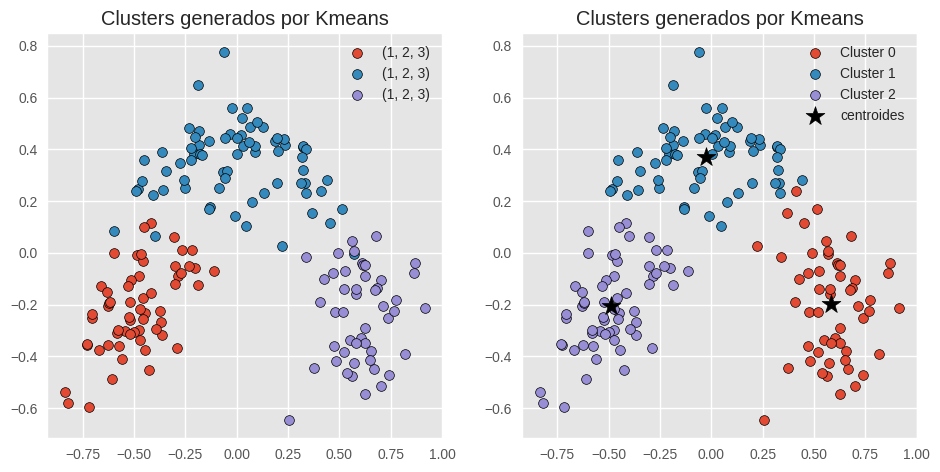

In [ ]:

# Representación gráfica: grupos originales vs clusters creados

 

# ==============================================================================

 

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
# Grupos originales

 

for i in np.unique(wine['target']):

 

    ax[0].scatter(

 

    
   x = pipe["preprocessor"].transform(wine['data'])[wine['target'] == i, 0],

 

y = pipe["preprocessor"].transform(wine['data'])[wine['target'] == i, 1],

 

        c = plt.rcParams['axes.prop_cycle'].by_key()['color'][i],

 

        marker    = 'o',

 

        edgecolor = 'black',

 

        label=(1,2,3)

 

    )

 

ax[0].set_title('Clusters generados por Kmeans')

 

ax[0].legend();

 

for i in np.unique(pipe["clusterer"]["kmeans"].labels_):

 

    ax[1].scatter(

 

        x = preprocessed_data[pipe["clusterer"]["kmeans"].labels_ == i, 0],

 

        y = preprocessed_data[pipe["clusterer"]["kmeans"].labels_ == i, 1],

 

        c = plt.rcParams['axes.prop_cycle'].by_key()['color'][i],

 

        marker    = 'o',

 

        edgecolor = 'black',

 

        label= f"Cluster {i}"

 

    )

 

ax[1].scatter(

 

   x = pipe["clusterer"]["kmeans"].cluster_centers_[:, 0],
    y = pipe["clusterer"]["kmeans"].cluster_centers_[:, 1],

 

    c = 'black',

 

    s = 200,

 

    marker = '*',

 

    label  = 'centroides'

 

)

 

ax[1].set_title('Clusters generados por Kmeans')

 

ax[1].legend();

#tiene menú contextual

**8. Genere la matriz de confusión para saber que tanto se equivocó el algoritmo.**

In [ ]:
pd.crosstab(wine['target'], pipe2["clusterer"]["dbscan"].labels_, dropna=False, rownames=['grupo_real'], colnames=['cluster'])

AttributeError: ignored

**9. Ahora repetiremos todo el procedimiento desde el paso 2 para analizar el desempeño 
de DBSCAN con la métrica Manhattan (cityblock).**

In [ ]:
preprocessor = Pipeline([
 ("scaler", MinMaxScaler()),
 ("pca", PCA(n_components=6, random_state=42)),])
pipe2 = Pipeline([("preprocessor", preprocessor)])
pipe2.fit(wine['data'])

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('scaler', MinMaxScaler()),
                                 ('pca',
                                  PCA(n_components=6, random_state=42))]))])

In [ ]:
DBS_clustering=DBSCAN(eps=p[0], min_samples=p[1],metric="cityblock").fit(X_numerics)


NameError: ignored